In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY") # type: ignore
llm=ChatOpenAI(model="gpt-5.4-mini")
result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 7, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DkkCisI1RADcMz5XkCk2bTryXf4cS', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e723d-1c7d-7df0-b9e8-4d6d9ae5e962-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 12, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [8]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

class State(TypedDict):
    topic:str
    characters:str
    settings:str
    premises:str
    story_intro:str

def generate_characters(state:State):
    """Generate character descriptions"""
    msg=llm.invoke(f"create two character name and brief for a story about {state["topic"]}")
    return {"characters":msg.content}

def generte_settings(state:State):
    """Generate story setting"""
    msg=llm.invoke(f"Describe a vivid setting for a story about {state["topic"]}")
    return {"settings":msg.content}

def generate_premises(state:State):
    """Generate story premises"""
    msg=llm.invoke(f"Wrie a one sentenc story about {state["topic"]}")
    return {"premises":msg.content}


def combine_elements(state:State):
    """Combine characters, setting and premises into an intro"""
    msg=llm.invoke(
        f"write a short story intoduction using these elements:\n"
        f"Characters: {state['characters']}\n"
        f"Setting: {state['settings']}\n"
        f"Premise: {state['premises']}"
        
    )
    return {"story_intro":msg.content}

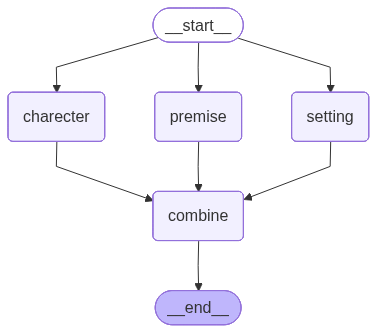

In [9]:
graph = StateGraph(State)

graph.add_node("charecter",generate_characters)
graph.add_node("setting",generte_settings)
graph.add_node("premise",generate_premises)
graph.add_node("combine",combine_elements)

graph.add_edge(START,"charecter")
graph.add_edge(START,"setting")
graph.add_edge(START,"premise")
graph.add_edge("charecter","combine")
graph.add_edge("setting","combine")
graph.add_edge("premise","combine")
graph.add_edge("combine",END)

compiled_graph = graph.compile()
display(Image(compiled_graph.get_graph().draw_mermaid_png()))

In [10]:
state= {"topic":"time travel"}
result = compiled_graph.invoke(state)
print(result["story_intro"])

At the edge of a forgotten city, where the river slowed into black glass and the streets tilted beneath the weight of centuries, stood the Observatory of Last Light. By day it looked abandoned—a half-collapsed clocktower of cracked stone and ivy—but at dusk it woke, its tarnished copper dome catching the last bruised gold of the sun.

Elian Voss had spent three years cataloging the observatory’s dust-choked archives, convinced the place was only a relic of dead experiments. He was a historian by trade and cautious by nature, the kind of man who trusted footnotes more than miracles. So when he found the device hidden beneath the floorboards—a circular platform of black iron and pale glass, ringed with trembling dials—his first instinct was to step back.

His second was to study it.

The machine hummed like a trapped storm. Brass pipes lined the walls, ticking softly in the cold air, while the broken pendulum above the platform swung with no rhythm at all. On the cracked glass of the con